In [1]:
import os
import xlrd
import pickle

import xlrd
import pickle
import spacy
import math
import string
import random
import collections
import matplotlib.pyplot as plt
from random import shuffle
import pandas as pd
import numpy as np
import re
#import bio
#import biopython

# spacy for lemmatization
import spacy

# Sklearn
from sklearn.naive_bayes import MultinomialNB

from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics.pairwise import euclidean_distances
from pprint import pprint



#from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import LinearSVC,SVC


# Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess

from gensim.models import LdaModel, LdaMulticore, CoherenceModel
from gensim.models.phrases import Phrases, Phraser
from gensim import models
# removido: gensim.models.wrappers nao existe mais a partir do gensim 4.x
# LdaMallet agora vem de um arquivo externo (notebooks/ldamallet_compat.py), vendorizado do gensim==3.8.3
from ldamallet_compat import LdaMallet




#from gensim.summarization import summarize, keywords  # removido: modulo nao existe mais no gensim 4.x (nao utilizado no notebook)
from pprint import pprint

# Plotting tools
import pyLDAvis
#import pyLDAvis.sklearn  # removido: submodulo nao existe mais no pyLDAvis 3.4.x (nao utilizado no notebook)

import pyLDAvis
import pyLDAvis.gensim  
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
%matplotlib inline


# NLTK Stop words
from nltk.corpus import stopwords

# NLTK Stop words
from nltk.corpus import stopwords
stop_words = stopwords.words('english')

#Essa lista de palavras básicas da lingua inglesa está sendo montada para ser exclusivamente forçada a sua exclusão 
#Com isso é esperado um maior acerto na clasificação dos topícos e os seus documentos. Obs: pode ser acrescentado 
#mais paralavras a tal lista se for necessário
stop_words.extend(['from', 'subject', 're', 'edu', 'use', 'not', 'would', 'say', 'could', '_', 
                   'be', 'know', 'good', 'go', 'get', 'do', 'done', 'try', 'many', 'some', 'nice', 
                   'thank', 'think', 'see', 'rather', 'easy', 'easily', 'lot', 'lack', 'make', 
                   'want', 'seem', 'run', 'need', 'even', 'right', 'line', 'even', 'also', 'may', 
                   'take', 'come'])



# Enable logging for gensim - optional
import logging
import warnings
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.ERROR)

warnings.filterwarnings("ignore",category=DeprecationWarning)

# Set up log to external log file
logging.basicConfig(filename='lda_model.log', format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

# Set up log to terminal
#logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO


In [2]:
SO = os.name
clear = ""
if SO == 'posix':
    patchExcel = "/mnt/LWH/learning/proj/personal_proj/TM/data/xlsx/"
    patchDAT   = "/mnt/LWH/learning/proj/personal_proj/TM/data/dat/"
    patchMallet = "/mnt/LWH/learning/proj/personal_proj/TM/tools/mallet-2.0.8/bin/mallet"
    clear = "clear"
elif SO == 'nt':
    patchExcel = "E:/DISSERTACAO2019/ProjetoTM/xlsx/"
    patchDAT   = "E:/DISSERTACAO2019/ProjetoTM/dat/"
    patchMallet = 'E:/DISSERTACAO2019/ProjetoTM/mallet/bin/mallet'
                
    clear = "cls"
else:
    print("Sistema Operacional não reconhecido")
    #break

#os.system(clear)
###### Read the classificaction data  (the training, validation and test sets) ######
os.chdir(os.path.dirname(patchExcel))
df = pd.read_excel('ArticleSelection_Sample_CP_RF_SB.xlsx', 'Indexes',index_col=None, header=None)
#lista_records = pd.read_excel('df_records.xlsx',index_col=None, header=None)


df2=df[df[1].notnull()]
isnotqm = df2[1]!='?'
df3=df2[isnotqm]
listinds = df3[0].tolist()
listclasses = df3[9].tolist()


del listinds[0]
del listclasses[0]
indsAndClasses = zip(listinds,listclasses) 

os.chdir(os.path.dirname(patchDAT))
with open("records.dat", "rb") as fp:   # Unpickling
    records = pickle.load(fp)

    
data = [[ic[0],ic[1],records[ic[0]]['TI'],records[ic[0]]['AB']] for ic in indsAndClasses]

#random.shuffle(data)

df_data = pd.DataFrame(data)
df_data = df_data.reset_index()
df_data = df_data.rename(columns={0:'indice',1:'classificacao',2:'titulo',3:'abstract'})
#df_data.head(3)

print("\n\nDataframe desbalanceado.")
df_data.head()   
print("fim")



Dataframe desbalanceado.
fim


In [3]:
def preTokinizacao(sentencas):
    """Está devida função, ajuda no processo de tokenização do corpus 
    já deixando todas as palavras em minúsculos e retirando alguns tipos de pontuações. 
    """
    
    for sent in sentencas:
        sent = simple_preprocess(str(sent), deacc=True) #deacc=True ajuda na parte de retira de pontos e barras e espaços
        yield(sent)  
#fim def

In [4]:
def lematizacao(texts, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    """https://spacy.io/api/annotation"""
    
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent)) 
        texts_out.append(" ".join([token.lemma_ for token in doc if token.pos_ in allowed_postags]))
    return texts_out
#fim def

In [5]:
################################################################################################################################
    # Lematização mantendo apenas; substantivo, adj, vb, adv e nominal
def cleanTokensText(data, stop_words = stop_words, allowed_postags = ['NOUN', 'ADJ', 'VERB', 'ADV']):


        ##para uma boa aprciação e ótimos resultados, é recomendado o uso de bigramas
        # Construa os modelos bigram e trigram
        bigram =  Phrases(data, min_count=5, threshold=100) #limiar mais alto menos frases.
        trigram = Phrases(bigram[data], threshold=100)     #quanto mais alto esses valores de paramentros
                                                                               #mais difícil é a combinação das palavras com os bigrams

        #modelos de Ngramas
        bigram_mod =  Phraser(bigram)
        trigram_mod = Phraser(trigram)



        """Remove Stopwords, faz processod de Bigrams, Trigrams e  Lematização"""

        texts_doc = [[palavra for palavra in simple_preprocess(str(doc)) if palavra not in stop_words] for doc in data]

        texts_doc = [bigram_mod[doc] for doc in texts_doc]

        texts_doc = [trigram_mod[bigram_mod[doc]] for doc in texts_doc]

        texts_saida = []

        nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

        for sent in texts_doc:

            doc = nlp(" ".join(sent)) 
            texts_saida.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
        #fim for 

        # remove stopwords once more after lemmatization
        texts_saida = [[palavra for palavra in simple_preprocess(str(doc)) if palavra not in stop_words] for doc in texts_saida]    

        return texts_doc
    #fim def
    ###########################################################################################################################


In [6]:
def Calc_coerencias(dct, corpus, data, limit, start=2, step=3):
    
    
    #Como encontrar o número ideal de tópicos para a LDA
    """
    Minha abordagem para encontrar o número ideal de tópicos é construir muitos modelos de LDA com diferentes 
    valores do número de tópicos (k) e escolher o que fornece o maior valor de coerência.
    Escolha um 'k' que marca o fim de um rápido crescimento da coerência de tópicos geralmente oferece tópicos 
    significativos e interpretáveis. Escolher um valor ainda mais alto às vezes pode fornecer subtópicos mais granulares.

    Se você vir as mesmas palavras-chave repetidas em vários tópicos, provavelmente é um sinal de que o 'k' é muito grande.

    O (veja abaixo) treina vários modelos de LDA e fornece os modelos e suas pontuações de coerência 
    correspondentes.compute_coherence_values()

    """
    
    """
    Calcular a coerência c_v para vários números de tópicos

    Parâmetros:
     ----------
     dicionário: dicionário Gensim
     corpus: corpus Gensim
     textos: lista de textos de entrada
     limite: número máximo de tópicos

     Devoluções:
     -------
     model_list: Lista de modelos de tópicos do LDA
     coherence_values: valores de coerência correspondentes ao modelo LDA com o respectivo número de tópicos
    """
    
    lista_coerencia = []
    modelo_lista = []
    
    for num_topics in range(start, limit, step):
        
        modelo = LdaMallet(patchMallet, corpus=corpus, num_topics=num_topics, id2word=id2word)
        
        modelo_lista.append(modelo)
        model_coerencia = CoherenceModel(model=modelo, texts=data, dictionary=dct, coherence='c_v')
        lista_coerencia.append(model_coerencia.get_coherence())
    #fim for

    return modelo_lista, lista_coerencia
#fim funcao

##########################################################################################################################


Classificação 0: 265
Classificação 1: 62
Proporção.: 4.27 : 1


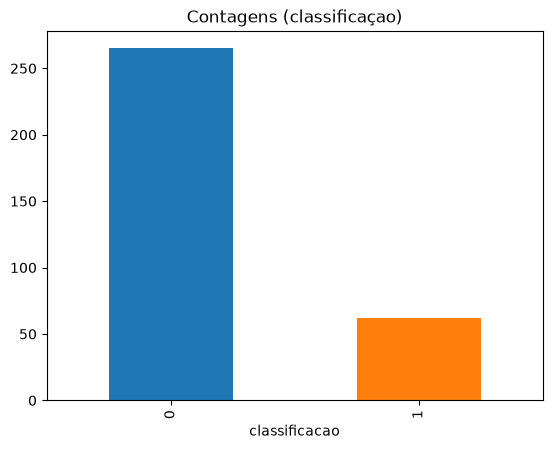

In [7]:
### Amostrage do desbalanceamento do corpus atual
df_desbalanceado = df_data.classificacao.value_counts()
print('Classificação 0:',df_desbalanceado[0])
print('Classificação 1:', df_desbalanceado[1])
print('Proporção.:', round(df_desbalanceado[0] / df_desbalanceado[1], 2), ': 1')

df_desbalanceado.plot(kind='bar', title='Contagens (classificaçao)',color = ['#1F77B4', '#FF7F0E']);


Probabilidade over-sampling:
classificacao
0    265
1    265
Name: count, dtype: int64


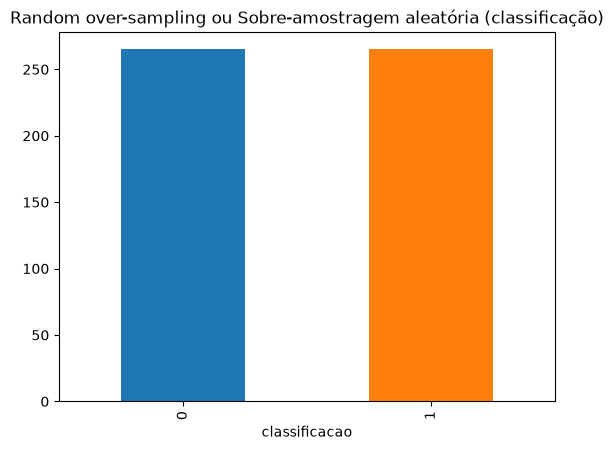

In [8]:
# Contagem de turmas 
# Parte do códico que faz o balaceamento utilizando de técnicas oversampling

#nesta parte  é colhido somente a classificação do corpus e feito a contegem do mesmo 
contagem_classe_0, contagem_classe_1 = df_data.classificacao.value_counts()

# separação  por classe
df_classe_0 = df_data[df_data['classificacao'] == 0]
df_classe_1 = df_data[df_data['classificacao'] == 1]


#Random over-sampling ou Sobre-amostragem aleatória
# Está parte faz a reamostragem elevando aleatoriamente com seus pesos respectivos a classe minoritaria
df_classe_1_over = df_classe_1.sample(contagem_classe_0, replace=True)

df_balanceado = pd.concat([df_classe_0, df_classe_1_over], axis=0)

print('Probabilidade over-sampling:')
print(df_balanceado.classificacao.value_counts())

df_balanceado.classificacao.value_counts().plot(kind='bar', 
                                               title='Random over-sampling ou Sobre-amostragem aleatória (classificação)',
                                               color = ['#1F77B4', '#FF7F0E']);


In [9]:
df_balanceado

,index,indice,classificacao,titulo,abstract
1,1,192,0,Health related quality of life and patient rep...,OBJECTIVE: To evaluate health-related quality ...
2,2,197,0,Effectiveness and tolerability of the buprenor...,BACKGROUND: A new transdermal delivery system ...
4,4,229,0,Gastric adenocarcinoma screening and preventio...,OBJECTIVE: To estimate the cost-effectiveness ...
5,5,231,0,Development of a disease specific health relat...,BACKGROUND: Health related quality of life (HR...
6,6,406,0,Subtypes of sleep problems in patients with Al...,OBJECTIVE: Sleep disturbances are common in pa...
...,...,...,...,...,...
14,14,631,1,Sleep is related to physical function and emot...,BACKGROUND: Emotional well-being and physical ...
171,171,9190,1,Correlations between physician-perceived funct...,BACKGROUND: Dyspnea and the resulting function...
122,122,6319,1,Health concerns predicts poor quality of life ...,PURPOSE: Most studies of quality of life (QOL)...
114,114,5828,1,Long-term functional and quality of life evalu...,BACKGROUND: The purpose of this study was to c...


In [10]:
type(df_balanceado)

pandas.DataFrame

In [11]:
#data = df_data.values.tolist() # dataframe sem balanceamento
data = df_balanceado.values.tolist() # ddataframe com  balaceamento

In [12]:
data

[[1,
  192,
  0,
  'Health related quality of life and patient reported symptoms before and during definitive radio(chemo)therapy using image-guided adaptive brachytherapy for locally advanced cervical cancer and early recovery - a mono-institutional prospective study.',
  'OBJECTIVE: To evaluate health-related quality of life (HR-QoL) and patient reported symptoms (PRS) before, during and early after treatment with external-beam radiotherapy (EBRT), chemotherapy and image-guided adaptive brachytherapy (IGABT) for locally advanced cervical cancer. METHODS: In fifty consecutive patients, HR-QoL and PRS were prospectively assessed with the EORTC-QLQ-C30+CX24 questionnaire prior to and during treatment, one week after IGABT and three months thereafter. HR-QoL was compared to an age-matched, female normative reference population. Prevalence rates of individual PRS are presented and defined as "substantial", if reported as "quite a bit" or "very much". RESULTS: Global health status and phys

In [13]:
# faz a limpeza das sentenças de cada artigo envolvido no corpus
data_words = list(preTokinizacao(data))
data_lemmatized_LDA = cleanTokensText(data_words) #LDA


In [14]:
print("Tamanho do corpus..: ",len(data_lemmatized_LDA))

Tamanho do corpus..:  530


In [15]:
#Classificação usando LDA para mostrar os pricipais documentos e seus tópicos

In [16]:
#Crie o dicionário e o corpus necessários para a modelagem de tópicos
"""As duas entradas principais para o modelo de tópico 
       LDA, são o dicionário ( id2word) e o corpus. """

# criando dicionario
id2word = corpora.Dictionary(data_lemmatized_LDA)

# criando corpus (BoW)
corpus = [id2word.doc2bow(texto) for texto in data_lemmatized_LDA]

cont_termos = [[(id2word[id], cont) for id, cont in linha] for linha in corpus]
bow = pd.DataFrame(cont_termos)

In [17]:
bow

,0,1,2,3,4,5,6,7,8,9,...,382,383,384,385,386,387,388,389,390,391
0,"(active, 1)","(adaptive, 2)","(additional, 1)","(advanced, 2)","(age, 1)","(although, 1)","(aspects, 1)","(assessed, 1)","(baseline, 1)","(beam, 1)",...,None,None,None,None,None,None,None,None,None,None
1,"(age, 2)","(assessed, 2)","(baseline, 2)","(cancer, 3)","(life, 3)","(methods, 1)","(months, 3)","(objective, 1)","(patients, 13)","(period, 3)",...,None,None,None,None,None,None,None,None,None,None
2,"(age, 2)","(although, 2)","(cancer, 3)","(conclusions, 1)","(found, 1)","(life, 1)","(objective, 1)","(one, 1)","(population, 3)","(prevalence, 1)",...,None,None,None,None,None,None,None,None,None,None
3,"(conclusions, 1)","(different, 1)","(found, 1)","(functioning, 3)","(health, 3)","(levels, 1)","(life, 3)","(methods, 1)","(patients, 1)","(quality, 3)",...,None,None,None,None,None,None,None,None,None,None
4,"(assessed, 1)","(evaluate, 1)","(functional, 3)","(life, 1)","(methods, 1)","(objective, 1)","(patient, 6)","(patients, 10)","(patterns, 1)","(quality, 1)",...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,"(age, 1)","(baseline, 1)","(conclusions, 1)","(emotional, 7)","(functional, 1)","(life, 1)","(methods, 1)","(objective, 1)","(patients, 1)","(patterns, 2)",...,None,None,None,None,None,None,None,None,None,None
526,"(additional, 1)","(conclusions, 1)","(evaluate, 2)","(functional, 7)","(health, 3)","(life, 2)","(methods, 1)","(objective, 3)","(patient, 4)","(patients, 1)",...,None,None,None,None,None,None,None,None,None,None
527,"(assessed, 1)","(comprehensive, 1)","(findings, 2)","(health, 5)","(life, 3)","(methods, 1)","(near, 1)","(patients, 2)","(qol, 8)","(quality, 3)",...,None,None,None,None,None,None,None,None,None,None
528,"(advanced, 2)","(cancer, 3)","(eortc_qlq, 2)","(functional, 3)","(life, 4)","(methods, 1)","(observed, 2)","(patients, 7)","(qol, 4)","(quality, 4)",...,None,None,None,None,None,None,None,None,None,None


In [18]:
#modelos de LDA,Mallet, Coerència e Perplexidade
#criando modelo LDA (obs: o método LdaMultiCore é utilizado espeiclamente para fins de processadores multicore)

import time
inicio = time.time()

cpu_count = 8

#%time
MODELO_LDA = LdaMulticore(corpus              =corpus,   # corpus
                          id2word =id2word,               #dicionário 
                          random_state        =20,      #Faz o embaralhamento aleatório do corpus, quanto maior o numero de estados mais lento se torna
                          num_topics          =50,     #O número de tópicos latentes solicitados a serem extraídos do corpus de treinamento.
                          passes              =20,      #Número de passes pelo corpus durante o treinamento, faz uma revisão de todos os passos.
                          chunksize           =50,     #Número de documentos a serem usados em cada bloco de treinamento.
                          batch               =False,
                          alpha               ='asymmetric',#multicore
                          decay               =0.5, 
                          offset              =64,         #Hiper-parâmetro que controla quanto desaceleraremos os primeiros passos nas primeiras iterações.
                          eta                 =None,
                          eval_every          =1,         #A perplexidade do log é estimada a cada atualização. Definir isso como um diminui o treinamento em ~ 2x.
                          iterations          =100,       #Número máximo de iterações através do corpus ao inferir a distribuição de tópicos de um corpus.
                          gamma_threshold     =0.002,     #Alteração mínima no valor dos parâmetros gama para continuar iterando
                          per_word_topics     =True,
                          workers = cpu_count -1 )



fim = time.time()
########################## Lengda dos paramentors da função LdaMulticore#############################################################################
# id2word: gensim.corpora.dictionary.Dictionary}) - Mapeando de IDs de palavras para palavras. 
#           É usado para determinar o tamanho do vocabulário, 
#           bem como para depuração e impressão de tópicos.

# alpha ( {numpy.ndarray , str} , opcional ) - Pode ser definido como uma matriz 1D de comprimento igual ao número de tópicos 
#                                               esperados que expressa nossa crença a priori na probabilidade de cada tópico. 
#                                                Como alternativa, as estratégias de seleção anteriores padrão podem ser empregadas 
#                                                fornecendo uma sequência:
#                                                            'asymmetric': usa uma assimétrica normalizada fixa anterior a 1.0 / topicno .
#                                                             'auto': aprende um anterior assimétrico do corpus (não disponível se distributed==True ).

# decay ( float , opcional ): - Um número entre (0,5, 1] para ponderar qual porcentagem do valor 
#                                                       lambda anterior é esquecida quando cada novo documento é #per_word_topics ( bool ) - 
#                                                       Se True, o modelo também calcula uma lista de tópicos, classificados em ordem decrescente 
#                                                       dos tópicos mais prováveis ​​para cada palavra, juntamente com seus valores phi multiplicados 
#                                                       pelo comprimento do recurso (ou seja, contagem de palavras).
#
# per_word_topics ( bool ) - Se True, o modelo também calcula uma lista de tópicos, classificados em ordem decrescente dos tópicos 
#                            mais prováveis para cada palavra, juntamente com seus valores phi multiplicados pelo comprimento 
#                            do recurso (ou seja, contagem de palavras).

# eta ( {float , np.array , str} , opcional ) - Crença a priori na probabilidade de palavras, pode ser:
#
#                                                escalar para uma probabilidade simétrica anterior ao tópico / palavra,
#
#                                                vetor de comprimento num_words para indicar uma probabilidade assimétrica definida pelo usuário para cada palavra,
#
#                                                matriz de forma (num_topics, num_words) para atribuir uma probabilidade para cada combinação palavra-tópico,
#
#                                                a string 'auto' para aprender o anterior assimétrico a partir dos dados.


#Fonte: https://radimrehurek.com/gensim/models/ldamodel.html
print(round(fim - inicio,5),"/s")

2.12756 /s


In [19]:
#modelo de coerência LDA
inicio = time.time()
modelo_coerencia_lda = CoherenceModel(model      = MODELO_LDA, 
                                     texts       = data_lemmatized_LDA, 
                                     dictionary  = id2word, 
                                     coherence   ='c_v' 
                                     )

#coerência lda sem mallet
coerenciaLDA = modelo_coerencia_lda.get_coherence()

#############Legenda dos parâmetros que CoherenceModel aceita ######
#   modelo ( BaseTopicModelopcional) - modelo de tópico pré-treinado, deve ser fornecido se o tópico não for fornecido. 
#                                      Atualmente suporta LdaModel, LdaMulticore, LdaMallete LdaVowpalWabbit. 
#                                      Use o parâmetro topics para conectar um modelo ainda não suportado.
#
#  texts - Textos tokenizados, necessários para modelos de coerência que usam estimador de probabilidade baseado em 
#          janela deslizante (isto é, coerência = `c_something`).  
#
#  dictionary -( Dictionary, opcional) - mapeamento no dicionário Gensim da palavra id para criar corpus. 
#                                        Se model.id2word estiver presente, isso não será necessário. 
#                                        Se ambos forem fornecidos, o dicionário aprovado será usado.
#
#  coherence ({'u_mass', 'c_v', 'c_uci', 'c_npmi'}, optional) - Medida de coerência a ser usada. Método mais rápido - 'u_mass', 'c_uci' 
#                                                  também conhecido como c_pmi . Para o corpus 'u_mass' deve ser fornecido, se houver textos,
#                                                  ele será convertido em corpus usando o dicionário. Para 'c_v', 'c_uci' e 'c_npmi' textos devem 
#                                                  ter fornecidos ( corpus não é necessário)
#
#Fonte: https://radimrehurek.com/gensim/models/coherencemodel.html
fim = time.time()
print(round(fim - inicio,2),"/s")


1.01 /s


In [20]:
##########################################--MALLET--####################################################################
#Uso da biblioteca mallet com LDA 

inicio = time.time()
MalletLDA   = LdaMallet(patchMallet,            # Caminho para o binário do mallet, por exemplo
                        corpus       = corpus,  # - Coleção de textos no formato BoW.
                        num_topics   =100,      #Número de tópicos.
                        id2word      =id2word   # O mapeamento entre IDs de tokens e palavras do corpus, se não especificado - 
                                                # será deduzido do corpus .
                        )
fim = time.time()
print(round(fim - inicio,5),"/s")

Mallet LDA: 100 topics, 7 topic bits, 1111111 topic mask
Data loaded.
max tokens: 759
total tokens: 80273
<10> LL/token: -8,61369
<20> LL/token: -8,10269
<30> LL/token: -7,9399
<40> LL/token: -7,85304

0	0,5	groups thresholds sagittal worse significantly outcomes surgical based correction study corrected strabismus hrqol methods benefit index reached profile conclusion younger 
1	0,5	quality psychosocial life idiopathic young pediatric nt case health effect results profile control methods study correlated school age evaluated treatment 
2	0,5	life quality effects laryngectomy voice survey voice_handicap_index analysis statistically adverse patients average statistical university questions determine physical emotional washington differences 
3	0,5	quality activity correlation syndrome binocular life evaluated anxiety evaluate pss correlated scale found relationship negative primary_sjogren assess reduced functional index 
4	0,5	treatment cost outcomes costs cost_effectiveness model nutr

31.6429 /s


In [21]:
#Obtendo o modelo de coerência da biblioteca mallet
inicio = time.time()
modeloCoerencia_Mallet = CoherenceModel(   model         =MalletLDA, 
                                           texts         =data_lemmatized_LDA, 
                                           dictionary    =id2word, 
                                           coherence     ='c_v'
                                           )

#resultado da coerência obtido da biblioteca mallet
coerenciaMallet = modeloCoerencia_Mallet.get_coherence()
fim = time.time()
print(round(fim - inicio,5),"/s")

2.31733 /s


In [22]:
# Pode levar muito tempo para ser executado dependendo da máquina
#calcula o melhor valor de coerência entre os topicos.
#esse cálculo de coerência é feito em cima do modelo lda utilizando bibliteca mallet
inicio = time.time()
lista_De_modelo, lista_valor_coerencia = Calc_coerencias(dct     =id2word, 
                                                         corpus  =corpus, 
                                                         data    =data_lemmatized_LDA, 
                                                         start   =2, 
                                                         limit   =50, 
                                                         step    =6) 
fim = time.time()
print(round(fim - inicio,5),"/s")

Mallet LDA: 2 topics, 1 topic bits, 1 topic mask
Data loaded.
max tokens: 759
total tokens: 80273
<10> LL/token: -8,08466
<20> LL/token: -7,92765
<30> LL/token: -7,8746
<40> LL/token: -7,8466

0	25	patients life quality study health qol questionnaire epilepsy results scores years children group significantly related score significant groups analysis age 
1	25	sleep quality patients clinical disease treatment outcomes hrqol health symptoms study patient reported related impact pain results conclusions life methods 

<50> LL/token: -7,83526
<60> LL/token: -7,82538
<70> LL/token: -7,82073
<80> LL/token: -7,81483
<90> LL/token: -7,81694

0	25	patients life quality study health qol results scores questionnaire epilepsy related children years significant group score groups age significantly analysis 
1	25	sleep quality patients treatment disease clinical outcomes health hrqol reported patient symptoms study related life included chronic compared months women 

<100> LL/token: -7,81368
<110> 

255.23448 /s


In [23]:
#pré-resultados
print("Uso do LDA\nModelo de Topicos")
pprint(MODELO_LDA.print_topics())

print('\nPerplexidade(LDA)..: ', MODELO_LDA.log_perplexity(corpus))
print('\nPontos da Coerência(LDA)..: ', coerenciaLDA)
print("*"*100)

Uso do LDA
Modelo de Topicos
[(np.int64(49),
  '0.000*"patients" + 0.000*"greater" + 0.000*"bdd" + 0.000*"treatment" + '
  '0.000*"group" + 0.000*"eating_disorder" + 0.000*"restrictions" + '
  '0.000*"subjects" + 0.000*"significant" + 0.000*"quality"'),
 (np.int64(48),
  '0.041*"visual" + 0.030*"vision" + 0.022*"wva" + 0.021*"function" + '
  '0.021*"binocular" + 0.017*"age" + 0.016*"dystrophy" + 0.015*"composite" + '
  '0.015*"patients" + 0.014*"tests"'),
 (np.int64(47),
  '0.045*"qol" + 0.032*"epilepsy" + 0.029*"child" + 0.028*"health" + '
  '0.023*"mental" + 0.022*"sleep" + 0.020*"well" + 0.019*"quality" + '
  '0.019*"life" + 0.017*"children"'),
 (np.int64(46),
  '0.018*"appraisal" + 0.013*"thentest" + 0.010*"discrepancy" + '
  '0.010*"ipsative" + 0.010*"recall" + 0.008*"bias" + 0.007*"normative" + '
  '0.005*"rs" + 0.005*"coded" + 0.005*"recalibration"'),
 (np.int64(45),
  '0.026*"patients" + 0.023*"sleep" + 0.023*"quality" + 0.018*"anxiety" + '
  '0.015*"life" + 0.015*"depression" 

In [24]:
"""
O objeto MODELO_LDA suporta indexação. Ou seja, se você passar um documento (lista de palavras) para o MODELO_LDA, 
ele fornece três coisas:

           * Os tópicos aos quais o documento pertence juntamente com a porcentagem.
           * Os tópicos a que cada palavra desse documento pertence.
           * O (s) tópico (s) em que cada palavra desse documento pertence aos valores AND phi.

Então, qual é o valor phi?

O valor phi é a probabilidade da palavra pertencer a esse tópico em particular. E a soma dos valores de phi para uma determinada palavra se soma ao número de vezes que a palavra ocorreu nesse documento.

"""
print("Resultados da classificação LDA para cada Topíco junto com seu valor Phi.(Três topícos exemplos)")
print("-"*80,"\n")
for c in MODELO_LDA[corpus[1:3]]:#MODELO_LDA 5:8
    print("(Topic Doc),(%) ..:",c[0])                                              # [(Topics, Perc Contrib)]
    print("Valor Phi (palav id)..:",c[2][:2])                                      # [(Word id, [(Topic, Phi Value)])]
    print("Palavra, Topic..:",[(id2word[wd], topic) for wd, topic in c[1][:2]])    # [(Word, [Topics])]
    print("Valor Phi (palav)..:",[(id2word[wd], topic) for wd, topic in c[2][:2]]) # [(Word, [(Topic, Phi Value)])]
    print()
#fim for

print("*"*150,"\n\n")

for c in MODELO_LDA[corpus[5:8]]:#MODELO_LDA 5:8
    print("(Topic Doc),(%) ..:",c[0])                                              # [(Topics, Perc Contrib)]
    print("Valor Phi (palav id)..:",c[2][:2])                                      # [(Word id, [(Topic, Phi Value)])]
    print("Palavra, Topic..:",[(id2word[wd], topic) for wd, topic in c[1][:2]])    # [(Word, [Topics])]
    print("Valor Phi (palav)..:",[(id2word[wd], topic) for wd, topic in c[2][:2]]) # [(Word, [(Topic, Phi Value)])]
    print()
#fim for

Resultados da classificação LDA para cada Topíco junto com seu valor Phi.(Três topícos exemplos)
-------------------------------------------------------------------------------- 

(Topic Doc),(%) ..: [(31, np.float32(0.18902196)), (37, np.float32(0.8068688))]
Valor Phi (palav id)..: [(4, [(31, np.float32(0.35001415)), (37, np.float32(1.649936))]), (7, [(31, np.float32(0.79442513)), (37, np.float32(1.2053847))])]
Palavra, Topic..: [('age', [37, 31]), ('assessed', [37, 31])]
Valor Phi (palav)..: [('age', [(31, np.float32(0.35001415)), (37, np.float32(1.649936))]), ('assessed', [(31, np.float32(0.79442513)), (37, np.float32(1.2053847))])]

(Topic Doc),(%) ..: [(23, np.float32(0.7316171)), (37, np.float32(0.2630299))]
Valor Phi (palav id)..: [(4, [(37, np.float32(1.9990212))]), (5, [(37, np.float32(1.9991534))])]
Palavra, Topic..: [('age', [37]), ('although', [37])]
Valor Phi (palav)..: [('age', [(37, np.float32(1.9990212))]), ('although', [(37, np.float32(1.9991534))])]

*****************

In [25]:
#Visualize os tópicos-palavras-chave
inicio = time.time()

pyLDAvis.enable_notebook()
visao = pyLDAvis.gensim.prepare(MODELO_LDA, corpus, id2word, mds='mmds')
#pyLDAvis.save_html(visao,'/mnt/d/micha/Documents/_EstudosUdemy/ProjetoTM/SVM_LDA_0.2v_passe_25_numTopic_100.html')
#os.system(" http://127.0.0.1:8888/mnt/d/micha/Documents/_EstudosUdemy/ProjetoTM/SVM_LDA_0.2v_passe_25_numTopic_100.html")
visao

fim = time.time()
print(round(fim - inicio,5),"s")

1.84516 s


/mnt/LWH/learning/proj/personal_proj/TM/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/mnt/LWH/learning/proj/personal_proj/TM/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


In [26]:
visao

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
31    -0.003430  0.240055       1        1  33.327609
37     0.054662  0.253573       2        1  14.933692
45    -0.005048  0.353438       3        1   8.468204
47     0.021347  0.425310       4        1   4.116538
32     0.340009  0.167618       5        1   3.404787
41     0.295289  0.268095       6        1   3.138846
2     -0.121257  0.263797       7        1   2.878873
23    -0.317459 -0.185184       8        1   2.629729
5     -0.248206  0.328137       9        1   2.555312
3      0.236166  0.334228      10        1   2.427583
11     0.190652  0.253761      11        1   2.370648
4      0.119882  0.341914      12        1   2.247765
36    -0.365533  0.070024      13        1   1.938776
7     -0.141010  0.357081      14        1   1.831029
1      0.341666  0.076263      15        1   1.623267
21    -0.323521  0.171201      16        1   1.442861
6     -0.240305  0.208702      17        1   1.424543
40    -0.367376 -0.006088      18        1   1.173499
34     0.344883 -0.003907      19        1   1.064732
38     0.290458 -0.119973      20        1   1.038279
39    -0.246677  0.096206      21        1   0.905053
24     0.300626 -0.178796      22        1   0.684634
26     0.147441 -0.200496      23        1   0.512246
25    -0.004411 -0.358147      24        1   0.431111
48    -0.237664 -0.028559      25        1   0.407049
10     0.125383 -0.015742      26        1   0.373392
18     0.108358 -0.141084      27        1   0.306993
27    -0.120422 -0.117619      28        1   0.290783
0     -0.012486 -0.187823      29        1   0.277524
43     0.021934 -0.245277      30        1   0.246271
20    -0.107033 -0.275691      31        1   0.238790
9     -0.063430 -0.167559      32        1   0.228661
29    -0.145853 -0.201014      33        1   0.220066
16     0.084097 -0.230369      34        1   0.213051
14    -0.038211 -0.110178      35        1   0.129619
46     0.023424 -0.132855      36        1   0.104345
35     0.042288 -0.100594      37        1   0.099556
33    -0.015333 -0.067981      38        1   0.086176
44     0.010969 -0.073466      39        1   0.061891
19     0.001771 -0.087100      40        1   0.037119
8      0.002257 -0.097079      41        1   0.018872
12     0.002535 -0.095423      42        1   0.014914
13     0.002217 -0.098208      43        1   0.014171
15     0.002341 -0.096971      44        1   0.012887
17     0.002288 -0.098076      45        1   0.011816
22     0.002435 -0.097343      46        1   0.009784
28     0.002221 -0.098435      47        1   0.008110
30     0.002360 -0.097550      48        1   0.007672
42     0.002246 -0.097878      49        1   0.005796
49     0.002459 -0.096939      50        1   0.005073, topic_info=            Term         Freq        Total Category  logprob  loglift
79      patients  2110.000000  2110.000000  Default  30.0000  30.0000
462        sleep   848.000000   848.000000  Default  29.0000  29.0000
482     epilepsy   334.000000   334.000000  Default  28.0000  28.0000
94       quality  1242.000000  1242.000000  Default  27.0000  27.0000
93           qol   416.000000   416.000000  Default  26.0000  26.0000
..           ...          ...          ...      ...      ...      ...
614  differences     0.000850   124.675846  Topic50  -8.5441  -2.0072
295     outcomes     0.000853   321.444491  Topic50  -8.5398  -2.9500
49        health     0.000855   733.121811  Topic50  -8.5374  -3.7721
446       groups     0.000837   254.812270  Topic50  -8.5592  -2.7371
647      symptom     0.000820   102.976948  Topic50  -8.5793  -1.8512

[3146 rows x 6 columns], token_table=      Topic      Freq                               Term
term                                                    
3384      1  0.643457                               aasm
5997     13  0.844254                          abatacept
6353      6  0.947977  abdominal_bleeding_a

In [27]:
# imprimir topicos com a utlização do mallte
print("\nUso do Mallete\nModelo de Topicos\n")
pprint(MalletLDA.show_topics(formatted=True))
print('\nPontos de Coerência (Uso de Mallet)..: ',coerenciaMallet,"\n\n")


Uso do Mallete
Modelo de Topicos

[(np.int64(49),
  '0.037*"binocular" + 0.035*"visual" + 0.032*"patients" + 0.027*"vision" + '
  '0.027*"cm" + 0.024*"function" + 0.019*"objective" + 0.019*"postoperative" + '
  '0.019*"age" + 0.018*"ph"'),
 (np.int64(79),
  '0.078*"anxiety" + 0.075*"depression" + 0.063*"patients" + 0.033*"hads" + '
  '0.026*"effect" + 0.023*"life" + 0.021*"lcm" + 0.021*"epilepsy" + '
  '0.020*"quality" + 0.018*"control"'),
 (np.int64(77),
  '0.088*"problems" + 0.050*"disorders" + 0.043*"infection" + '
  '0.043*"prevalence" + 0.036*"infections" + 0.036*"background" + '
  '0.029*"increased" + 0.025*"past" + 0.025*"month" + 0.023*"cortisol"'),
 (np.int64(14),
  '0.146*"results" + 0.127*"methods" + 0.056*"medical" + 0.046*"conclusions" + '
  '0.037*"objectives" + 0.029*"questionnaire" + 0.029*"average" + '
  '0.021*"assessments" + 0.019*"diagnosis" + 0.017*"responses"'),
 (np.int64(98),
  '0.045*"srs" + 0.038*"adults" + 0.036*"status" + 0.035*"sf" + '
  '0.034*"instrument

In [28]:
#exibição para comparação entre os resultados de coerência do mallet e do LDA
print("Comparações com os valores de Coerências\n")
print('\nPerplexidade do modelo..: ',round(MODELO_LDA.log_perplexity(corpus),2))
#print('\nPontos da Coerência(LDA)..: ', round(coerenciaLDA,2))
print('\nPontos de Coerência do modelo..: ',round(coerenciaMallet,2),"\n\n")
print("*"*100)

Comparações com os valores de Coerências


Perplexidade do modelo..:  -7.51

Pontos de Coerência do modelo..:  0.44 


****************************************************************************************************


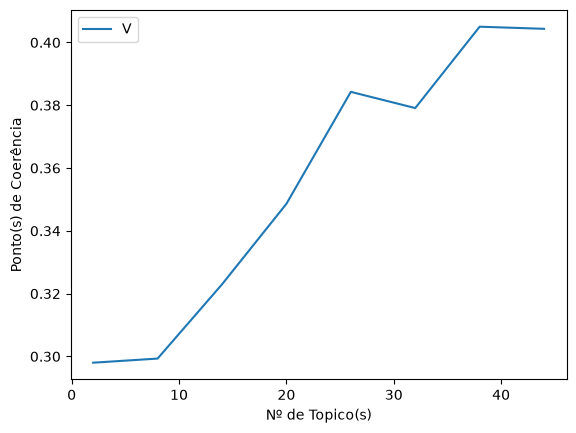

Grafico Gerado



In [29]:
# gráfico

limit=50; start=2; step=6;
sequencia = range(start, limit, step)
plt.plot(sequencia, lista_valor_coerencia)
plt.xlabel("Nº de Topico(s)")
plt.ylabel("Ponto(s) de Coerência")
plt.legend(("Valor da coerência"), loc='best')
plt.show()
print("Grafico Gerado\n")


In [30]:
# Imprimir as pontuações de coerência
listaCoerencia = []
for numeroTopic, cv in zip(sequencia, lista_valor_coerencia):
    print("Nº Topicos = ",numeroTopic, " tem um valor de coerência de ", round(cv, 2)*100,"%")
    listaCoerencia.append(cv)
    
#fim for 

MaiorCoerencia = max(listaCoerencia)
MaiorCoerencia = float(MaiorCoerencia)
print("\nMaior Coerencia..: ",round(MaiorCoerencia,2)*100,"%")

Nº Topicos =  2  tem um valor de coerência de  30.0 %
Nº Topicos =  8  tem um valor de coerência de  30.0 %
Nº Topicos =  14  tem um valor de coerência de  32.0 %
Nº Topicos =  20  tem um valor de coerência de  35.0 %
Nº Topicos =  26  tem um valor de coerência de  38.0 %
Nº Topicos =  32  tem um valor de coerência de  38.0 %
Nº Topicos =  38  tem um valor de coerência de  41.0 %
Nº Topicos =  44  tem um valor de coerência de  40.0 %

Maior Coerencia..:  41.0 %


In [31]:
# Selecione o modelo e imprima os tópicos
selecao_model_mallet = lista_De_modelo[3]#3

print("Visualização dos Tópicos com Mallet")
pprint(selecao_model_mallet.print_topics(num_words=10)) 

Visualização dos Tópicos com Mallet
[(0,
  '0.054*"epilepsy" + 0.042*"life" + 0.029*"related" + 0.029*"quality" + '
  '0.027*"study" + 0.025*"health" + 0.020*"qol" + 0.019*"children" + '
  '0.014*"results" + 0.012*"data"'),
 (1,
  '0.031*"pain" + 0.021*"analysis" + 0.017*"clinical" + 0.016*"outcomes" + '
  '0.016*"osa" + 0.015*"studies" + 0.015*"trials" + 0.011*"assessed" + '
  '0.010*"results" + 0.010*"response"'),
 (2,
  '0.041*"women" + 0.036*"health" + 0.035*"men" + 0.027*"sleep" + '
  '0.027*"problems" + 0.027*"symptoms" + 0.020*"related" + 0.020*"compared" + '
  '0.017*"differences" + 0.016*"males"'),
 (3,
  '0.054*"treatment" + 0.031*"group" + 0.026*"patients" + 0.017*"cancer" + '
  '0.017*"patient" + 0.012*"qol" + 0.012*"significant" + 0.010*"safety" + '
  '0.010*"total" + 0.009*"greater"'),
 (4,
  '0.032*"sleep" + 0.029*"treatment" + 0.025*"insomnia" + 0.023*"patients" + '
  '0.019*"quality" + 0.017*"group" + 0.017*"months" + 0.016*"scores" + '
  '0.014*"obstructive" + 0.014*"

In [32]:
#Encontrar o tópico dominante em cada frase
"""
Uma das aplicações práticas da modelagem de tópicos é determinar sobre qual tópico trata um determinado documento.

Para descobrir isso, encontramos o número do tópico que tem a maior porcentagem de contribuição nesse documento.

A função abaixo agrega essas informações em uma tabela apresentável .format_topics_sentences()
"""

def Topic_Domin_Frase(ldamodel=MODELO_LDA, corpus=corpus, docs=data):
    # Saída inicial
    topic_data = []

    # Obter tópico principal em cada documento
    for cont, linha in enumerate(ldamodel[corpus]):
        
        linha = sorted(linha, key=lambda x: (x[1]), reverse=True)
        
        # Obter o tópico Dominante, Contribuição de porcentagem e Palavras-chave para cada documento
        for j, (numTopic,propriedadTopic) in enumerate(linha):
            if j == 0:  #topico dominante
                valor = ldamodel.show_topic(numTopic)
                topicPalavra_chave = ", ".join([texto for texto, prop in valor])
                
                topic_data.append({
                    0: int(numTopic),
                    1: round(propriedadTopic,2), #numero de casas decimais
                    2: topicPalavra_chave
                })
            else:
                break
            #fim if
        #fim for
    #fim for
    df_topic = pd.DataFrame(topic_data)
    df_topic.columns = ['Topic_Dominant', 'Perc_Contribuicao', 'Palavra_Chave']
    # Adicione texto original ao final da saída
    conteudo = pd.Series(docs)
    df_topic = pd.concat([df_topic, conteudo], axis=1)
    return(df_topic)
#fim funcao


TopicosPal_chaves = Topic_Domin_Frase(ldamodel=selecao_model_mallet, corpus=corpus, docs=data)

# Formatação
Df_Topic_Dominante = TopicosPal_chaves.reset_index()
Df_Topic_Dominante.columns = ['Nº_Doc', 'Topic_Dominant', 'Topic_Perc_Contrib', 'Palavra_Chave', 'Abstract']

# Show
print("Classificação do(s) Tópico(s) dominante(s) em cada frase.")
print("-"*80)
Df_Topic_Dominante.head()

Classificação do(s) Tópico(s) dominante(s) em cada frase.
--------------------------------------------------------------------------------


,Nº_Doc,Topic_Dominant,Topic_Perc_Contrib,Palavra_Chave,Abstract
0,0,3,0.23,"treatment, group, patients, cancer, patient, q...","[1, 192, 0, Health related quality of life and..."
1,1,3,0.31,"treatment, group, patients, cancer, patient, q...","[2, 197, 0, Effectiveness and tolerability of ..."
2,2,9,0.58,"screening, life, data, health, results, cost, ...","[4, 229, 0, Gastric adenocarcinoma screening a..."
3,3,6,0.36,"health, adults, study, specific, sf, instrumen...","[5, 231, 0, Development of a disease specific ..."
4,4,16,0.24,"sleep, quality, reported, clinical, study, com...","[6, 406, 0, Subtypes of sleep problems in pati..."


In [33]:
#Encontre o documento mais representativo para cada tópico
"""
Às vezes, apenas as palavras-chave do tópico podem não ser suficientes para entender o 
significado de um tópico. Portanto, para ajudar a entender o tópico, você pode encontrar 
os documentos que um determinado tópico mais contribuiu e inferir o tópico lendo esse documento. 
"""

# Agrupe as 5 principais frases em cada tópico
sentecas_topicMallet = pd.DataFrame()

sent_topics_outdf_grpd = TopicosPal_chaves.groupby('Topic_Dominant')

for i, grp in sent_topics_outdf_grpd:
    sentecas_topicMallet = pd.concat([sentecas_topicMallet, 
                                      grp.sort_values(['Perc_Contribuicao'], 
                                      ascending =[0]).head(1)], 
                                      axis=0
                                     )

    
# Redefinir índice
sentecas_topicMallet.reset_index(drop=True, inplace=True)

# formatação
sentecas_topicMallet.columns = [' Nº_Topic', "Topic_Perc_Contrib", "Palavra_Chave", "Abstract (Doc)"]

# Show
print("Documento mais representativo para cada tópico")
print("-"*80)
sentecas_topicMallet
#print(sentecas_topicMallet)

Documento mais representativo para cada tópico
--------------------------------------------------------------------------------


,Nº_Topic,Topic_Perc_Contrib,Palavra_Chave,Abstract (Doc)
0,0,0.66,"epilepsy, life, related, quality, study, healt...","[134, 6874, 1, Trajectories of health-related ..."
1,1,0.66,"pain, analysis, clinical, outcomes, osa, studi...","[31, 1209, 1, The efficacy of the OSA-18 as a ..."
2,2,0.69,"women, health, men, sleep, problems, symptoms,...","[140, 7155, 1, How Do Sleep-Related Health Pro..."
3,3,0.61,"treatment, group, patients, cancer, patient, q...","[44, 1983, 1, Comorbidity of body dysmorphic d..."
4,4,0.82,"sleep, treatment, insomnia, patients, quality,...","[35, 1482, 1, Psychological treatment for inso..."
5,5,0.61,"hiv, care, symptoms, gerd, management, symptom...","[10, 554, 1, Determination of ReQuest-based sy..."
6,6,0.76,"health, adults, study, specific, sf, instrumen...","[0, 138, 1, Studies in the modified Scoliosis ..."
7,7,0.68,"quality, sleep, scale, disease, life, syndrome...","[209, 11094, 1, Sleep quality in patients with..."
8,8,0.65,"patients, life, disease, score, negative, data...","[303, 15812, 1, Health-related Quality of Life..."
9,9,0.58,"screening, life, data, health, results, cost, ...","[4, 229, 0, Gastric adenocarcinoma screening a..."


In [34]:
Df_Topic_Dominante['Abstract']

0      [1, 192, 0, Health related quality of life and...
1      [2, 197, 0, Effectiveness and tolerability of ...
2      [4, 229, 0, Gastric adenocarcinoma screening a...
3      [5, 231, 0, Development of a disease specific ...
4      [6, 406, 0, Subtypes of sleep problems in pati...
                             ...                        
525    [14, 631, 1, Sleep is related to physical func...
526    [171, 9190, 1, Correlations between physician-...
527    [122, 6319, 1, Health concerns predicts poor q...
528    [114, 5828, 1, Long-term functional and qualit...
529    [183, 9963, 1, Quality-of-life in children and...
Name: Abstract, Length: 530, dtype: object

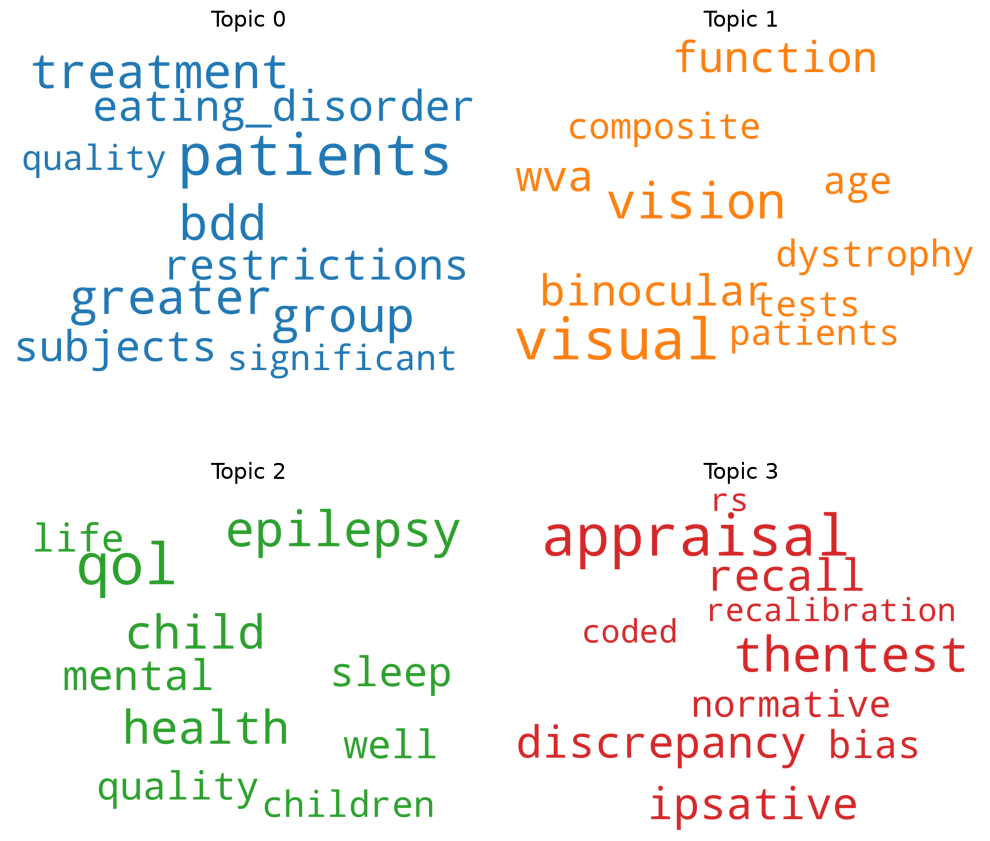

In [35]:
# 1. Wordcloud of Top N words in each topic
from matplotlib import pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import matplotlib.colors as mcolors

cols = [color for name, color in mcolors.TABLEAU_COLORS.items()]  # more colors: 'mcolors.XKCD_COLORS'

cloud = WordCloud(stopwords=stop_words,
                  background_color='white',
                  width=2500,
                  height=1800,
                  max_words=10,
                  colormap='tab10',
                  color_func=lambda *args, **kwargs: cols[i],
                  prefer_horizontal=1.0)

topics = MODELO_LDA.show_topics(formatted=False)

fig, axes = plt.subplots(2, 2, figsize=(10,10), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    fig.add_subplot(ax)
    topic_words = dict(topics[i][1])
    cloud.generate_from_frequencies(topic_words, max_font_size=300)
    plt.gca().imshow(cloud)
    plt.gca().set_title('Topic ' + str(i), fontdict=dict(size=16))
    plt.gca().axis('off')


plt.subplots_adjust(wspace=0, hspace=0)
plt.axis('off')
plt.margins(x=0, y=0)
plt.tight_layout()
plt.show()

In [36]:
import wordcloud
wordcloud.__version__

'1.9.6'

In [37]:
#Incio da classificação SVM com os resultados oriudos da classificação não supervisionada do LDA

In [38]:
#Como o processamento do SVM é diferente do LDA, é necessário fazer mais outro tratamento do novo corpus já processado pelo LDA
data_novo = Df_Topic_Dominante.values.tolist()
data_words_2 = list(preTokinizacao(data_novo))

# Faça a lematização mantendo apenas Substantivo, Adj, Verbo, Advérbio
data_lemmatized_SVM = lematizacao(data_words_2, 
                                  allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']) #svm

In [39]:
cont = 0
for texto in data_lemmatized_SVM:
    cont += 1
    print("Doc ",cont,"\n",texto,"\n")

Doc  1 
 treatment group patient cancer patient qol significant safety total great health relate quality life patient report symptom definitive radio chemo therapy use image guide adaptive brachytherapy locally advanced cervical cancer early recovery institutional prospective study objective evaluate health relate quality life hr qol patient report symptom prs before early treatment external beam radiotherapy chemotherapy image guide adaptive brachytherapy igabt locally advanced cervical cancer method consecutive patient hr prs prospectively assess eortc qlq cx questionnaire prior treatment week month thereafter hr compare age match female normative reference population prevalence rate individual prs present define as substantial report quite bit very much result global health status physical role function show highly significant decline treatment return baseline level month end treatment compare reference population global health status emotional role functioning remain impaired most 

In [40]:
#Escolhendo o melhor parâmetro parao modelo svm

# Remove colunas: 'index', 'titulo' e 'abstract' 
labels = df_balanceado.columns[1:3]

X = df_balanceado[labels]
y = df_balanceado['classificacao']

#Agora, vamos dividir nossos dados em trem e conjunto de testes com uma proporção de 70: 30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

model = SVC() 
model.fit(X_train, y_train) 
  
# print prediction results 
predictions = model.predict(X_test) 
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.53      0.46      0.50        56
           1       0.47      0.54      0.50        50

    accuracy                           0.50       106
   macro avg       0.50      0.50      0.50       106
weighted avg       0.50      0.50      0.50       106



In [41]:
#definindo faixa de parâmetros

param_grid = {'C': [0.1, 1, 10, 100, 1000],  
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
              'kernel': ['linear']}  
  
grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3) 
  
# ajuste do modelo para pesquisa em grade
grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.941 total time=   2.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.871 total time=  12.0s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.906 total time=   1.5s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.906 total time=   4.5s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.976 total time=   2.3s
[CV 1/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.941 total time=   2.0s
[CV 2/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.871 total time=  12.1s
[CV 3/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.906 total time=   1.5s
[CV 4/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.906 total time=   4.5s
[CV 5/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.976 total time=   2.4s
[CV 1/5] END ..C=0.1, gamma=0.01, kernel=linear;, score=0.941 total time=   2.0s
[CV 2/5] END ..C=0.1, gamma=0.01, kernel=linear

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['linear']}"
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` i

In [42]:
# imprimir o melhor parâmetro após o ajuste
print("Melhor parâmetro após o ajuste..: ",grid.best_params_) 
  
#imprima como nosso modelo cuida do ajuste de hiperparâmetros
print("\nMelhor Modelo para o SVM..:\n\n",grid.best_estimator_) 

Melhor parâmetro após o ajuste..:  {'C': 1, 'gamma': 1, 'kernel': 'linear'}

Melhor Modelo para o SVM..:

 SVC(C=1, gamma=1, kernel='linear')


In [43]:
grid_predictions = grid.predict(X_test) 
  
# imprimir relatório de classificação 
print(classification_report(y_test, grid_predictions)) 

              precision    recall  f1-score   support

           0       0.71      1.00      0.83        56
           1       1.00      0.54      0.70        50

    accuracy                           0.78       106
   macro avg       0.85      0.77      0.77       106
weighted avg       0.85      0.78      0.77       106



In [44]:
#modelos de classificadores SVM

SVC = SVC(C=0.1, cache_size=200, 
           class_weight=None, coef0=0.0,
           decision_function_shape='ovr', degree=3, 
           gamma=1, kernel='linear',
           max_iter=-1, probability=False, 
           random_state=None, shrinking=True,
           tol=0.001, verbose=False)
"""
SVC =  SVC(C=100, cache_size=200, 
           class_weight=None, coef0=0.0,
           decision_function_shape='ovr', 
           degree=3, gamma=1, kernel='rbf',
           max_iter=-1,
           probability=False, random_state=None, 
           shrinking=True, tol=0.001,
           verbose=False)
"""
#SVC  = SVC()# PURO

#SVC = LinearSVC()
print()

<>:99: SyntaxWarning: invalid escape sequence '\C'
<>:147: SyntaxWarning: invalid escape sequence '\C'
<>:99: SyntaxWarning: invalid escape sequence '\C'
<>:147: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_23724/4214498099.py:99: SyntaxWarning: invalid escape sequence '\C'
  print ("\n\Classificação SVM")
/tmp/ipykernel_23724/4214498099.py:147: SyntaxWarning: invalid escape sequence '\C'
  print ("\n\Classificação naveis bayes")
/mnt/LWH/learning/proj/personal_proj/TM/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/mnt/LWH/learning/proj/personal_proj/TM/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensembl


\Classificação SVM
Resultados: 

Precisão........:  83.8 % 
Renovação.......:  86.0 % 
Acuracia........:  85.0 % 
F1..............:  63.0 % 
TPR.............: 85.7 %
--------------------------------------------------

Matriz de confusão para classificador SVM

 [[221.  44.]
 [ 38. 227.]]


/mnt/LWH/learning/proj/personal_proj/TM/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/tmp/ipykernel_23724/4214498099.py:135: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([''] + rotulos_mx)
/tmp/ipykernel_23724/4214498099.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([''] + rotulos_mx)


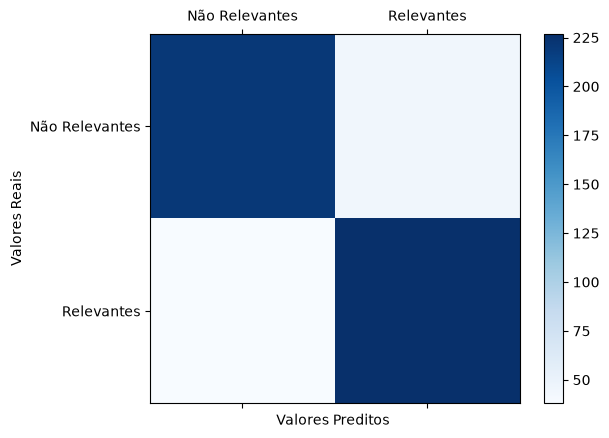

/tmp/ipykernel_23724/4214498099.py:183: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([''] + rotulos_mx)
/tmp/ipykernel_23724/4214498099.py:184: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([''] + rotulos_mx)





**************************************************

\Classificação naveis bayes
Resultados: 

Precisão........:  98.1 % 
Renovação.......:  60.0 % 
Acuracia........:  79.0 % 
F1..............:  55.00000000000001 % 
TPR.............: 60.0 %
--------------------------------------------------

Matriz de confusão para classificador naveis bayes 

 [[221.  44.]
 [ 38. 227.]]


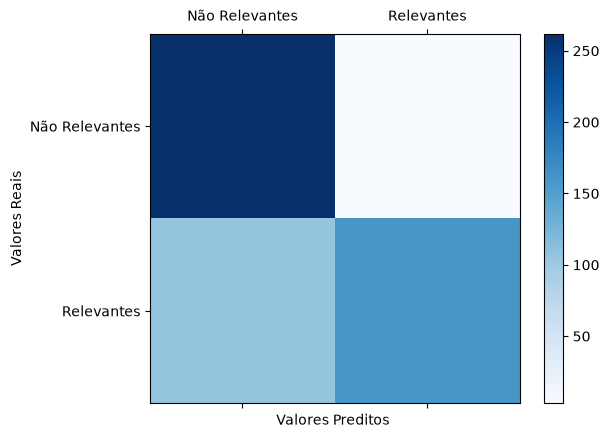

0.93412 s


In [45]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC,SVC

#Prepare vetores de recursos por correio de treinamento e seus rótulos
inicio = time.time()

ntotal = len(data_lemmatized_SVM)
meio = ntotal/2
meio = int(meio)

#Prepare vetores de recursos pelo treinamento de seus rótulos
rotulos = np.zeros(ntotal)
rotulos[0:meio]=0
rotulos[meio:ntotal]=1 

skfolds = StratifiedKFold(n_splits=4, shuffle=True, random_state=2)#3

totalsvm = 0
totalNB = 0

totalMatriz_svm = np.zeros((2,2))

totalMatrizNB = np.zeros((2,2));

#inicio do processso de k-folds 
for train_index, test_index in skfolds.split(data_lemmatized_SVM,rotulos):
    
    

    X_train = [data_lemmatized_SVM[i] for i in train_index]
    X_test = [data_lemmatized_SVM[i] for i in test_index]
    
   
    
    y_train, y_test =rotulos[train_index], rotulos[test_index]
    
   
    
    
    vectorizer = TfidfVectorizer(min_df=5,     #ignore os termos que tenham uma frequência de documento estritamente menor que o limite especificado
                                 max_df = 0.8, #ignore os termos que tenham uma frequência de documento estritamente maior que o limite fornecido (palavras de parada específicas do corpus)
                                 sublinear_tf=True, #Aplique a escala sublinear de tf, ou seja, substitua tf por 1 + log (tf).
                                 use_idf=True, #Ative a ponderação inversa da frequência de documentos.
                                 norm='l2',   # *
                                 encoding='utf-8',#Se forem fornecidos bytes ou arquivos para análise, essa codificação será usada para decodificar. 
                                 ngram_range=(1, 2), 
                                 stop_words='english')
    
    
    #################Documentação dos parâmetros do TfidfVectorizer##############################################################
    # * norm='l2':  Cada linha de saída terá a norma da unidade: *                                                              #
    #               l2': A soma dos quadrados dos elementos do vetor é 1.                                                       #
    #               A semelhança de cosseno entre dois vetores é seu produto escalar quando a norma l2 for aplicada.            #
    #               'L1': a soma dos valores absolutos dos elementos do vetor é 1                                               #
    #                                                                                                                           #
    #  *ngram_range: Os limites inferior e superior da faixa de n-valores para diferentes n-gramas a serem extraídos.           #
    #                 Todos os valores de n de modo que min_n <= n <= max_n serão usados.                                       #
    #  *stop_words: Se uma sequência, ela é passada para _check_stop_list e a lista de paradas apropriada é retornada.          #
    #                 "Inglês" atualmente é o único valor de string suportado. Existem vários problemas conhecidos com "inglês" #
    #                  e você deve considerar uma alternativa                                                                   #
    #############################################################################################################################
    
    train_corpus_tf_idf = vectorizer.fit_transform(X_train) 
    test_corpus_tf_idf  =  vectorizer.transform(X_test)
     
   
    modeloSVC = SVC(C=0.1, cache_size=200, 
                   class_weight=None, coef0=0.0,
                   decision_function_shape='ovr', degree=3, 
                   gamma=1, kernel='linear',
                   max_iter=-1, probability=False, 
                   random_state=None, shrinking=True,
                   tol=0.001, verbose=False)  # com hiper-parâmetro ajustado
    
    modeloNB = MultinomialNB()
    
    
    modeloSVC.fit(train_corpus_tf_idf,y_train)
    
    
    modeloNB.fit(train_corpus_tf_idf,y_train)
    
    result1 = modeloSVC.predict(test_corpus_tf_idf)
    result2 = modeloNB.predict(test_corpus_tf_idf)
    
    
    totalMatriz_svm = totalMatriz_svm + confusion_matrix(y_test, 
                                                 result1,
                                                 labels=[0,1])
    
    totalMatrizNB = totalMatrizNB + confusion_matrix(y_test, result2, labels=[0,1])
    
    
    totalsvm = totalsvm+sum(y_test==result1)   
    totalNB = totalNB+sum(y_test==result2)
#fim for

########################################################Métricas######################################################################################
print ("\n\Classificação SVM")
classeNegativa = totalMatriz_svm[0]
classePositiva = totalMatriz_svm[1]


TN = classeNegativa[0]
FP = classeNegativa[1]

FN = classePositiva[0]
TP = classePositiva[1]

precisao = TP/(TP+FP)
renovacao = TP/(TP+FN)
acuracia = (TP+TN)/(TP+TN+FP+FN)
F1 = TP/(TP+((FN+TP)/2))
TPR = TP/(TP+FN)



print("Resultados:","\n\nPrecisão........: ",(round(precisao,3)*100),"%",
                    "\nRenovação.......: ",(round(renovacao,2)*100),"%",
                    "\nAcuracia........: ",(round(acuracia,2)*100),"%",
                    "\nF1..............: ",(round(F1,2)*100),"%",
                    "\nTPR.............:",(round(TPR,3)*100),"%",)
print("-"*50)

print("\nMatriz de confusão para classificador SVM\n\n",totalMatriz_svm) 

rotulos_mx = ['Não Relevantes', 'Relevantes']

fig = plt.figure()
ax = fig.add_subplot(111)

cax = ax.matshow(totalMatriz_svm, cmap=plt.cm.Blues)
fig.colorbar(cax)

ax.set_xticklabels([''] + rotulos_mx)
ax.set_yticklabels([''] + rotulos_mx)

plt.xlabel('Valores Preditos ')
plt.ylabel('Valores Reais')
plt.show()

print("\n\n")

#####################################################################################################################################

print("*"*50)
print ("\n\Classificação naveis bayes")

classeNegativa = totalMatrizNB[0]
classePositiva = totalMatrizNB[1]


TN = classeNegativa[0]
FP = classeNegativa[1]

FN = classePositiva[0]
TP = classePositiva[1]

precisao = TP/(TP+FP)
renovacao = TP/(TP+FN)
acuracia = (TP+TN)/(TP+TN+FP+FN)
F1 = TP/(TP+((FN+TP)/2))
TPR = TP/(TP+FN)



print("Resultados:","\n\nPrecisão........: ",(round(precisao,3)*100),"%",
                    "\nRenovação.......: ",(round(renovacao,2)*100),"%",
                    "\nAcuracia........: ",(round(acuracia,2)*100),"%",
                    "\nF1..............: ",(round(F1,2)*100),"%",
                    "\nTPR.............:",(round(TPR,3)*100),"%",)
print("-"*50)
print("\nMatriz de confusão para classificador naveis bayes \n\n",totalMatriz_svm) 

rotulos_mx = ['Não Relevantes', 'Relevantes']

fig = plt.figure()
ax = fig.add_subplot(111)

cax = ax.matshow(totalMatrizNB, cmap=plt.cm.Blues)
fig.colorbar(cax)

ax.set_xticklabels([''] + rotulos_mx)
ax.set_yticklabels([''] + rotulos_mx)

plt.xlabel('Valores Preditos ')
plt.ylabel('Valores Reais')
plt.show()


fim = time.time()
print(round(fim - inicio,5),"s")